In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# Load Dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Agriculture.csv')
df

Saving Agriculture.csv to Agriculture.csv


,FarmerID,State,Gender,Age,Crop,FarmSize_Ha,Yield_Tons,AnnualRevenue_NGN,FertilizerUsed,LoanAmount_NGN
0,F0001,Lagos,female,35.0,Yam,3.92,54.20,NaN,Yes,249957.0
1,F0002,Borno,male,NaN,Yam,unknown,43.69,NaN,Yes,NaN
2,F0003,Kaduna,Female,NaN,Rice,2.77,NaN,NaN,Yes,3853935.0
3,F0004,Rivers,Male,NaN,Soybean,unknown,5.75,NaN,Yes,1952791.0
4,F0005,Enugu,female,NaN,Cassava,9.57,53.68,10269522.0,NaN,2053622.0
...,...,...,...,...,...,...,...,...,...,...
495,F0496,KANO,M,NaN,Soybean,unknown,62.51,8520971.0,Yes,4849736.0
496,F0497,KANO,Female,36.0,Maize,24.35,NaN,6198229.0,N,900303.0
497,F0498,Rivers,F,NaN,Yam,NaN,10.06,8769581.0,N,NaN
498,F0499,Lagos,Male,NaN,Rice,NaN,NaN,NaN,No,NaN


In [4]:
# check for missing values
df.isnull().sum()

,0
FarmerID,10
State,43
Gender,50
Age,335
Crop,0
FarmSize_Ha,162
Yield_Tons,239
AnnualRevenue_NGN,244
FertilizerUsed,105
LoanAmount_NGN,247


In [5]:
# remove duplicates
df.drop_duplicates()

,FarmerID,State,Gender,Age,Crop,FarmSize_Ha,Yield_Tons,AnnualRevenue_NGN,FertilizerUsed,LoanAmount_NGN
0,F0001,Lagos,female,35.0,Yam,3.92,54.20,NaN,Yes,249957.0
1,F0002,Borno,male,NaN,Yam,unknown,43.69,NaN,Yes,NaN
2,F0003,Kaduna,Female,NaN,Rice,2.77,NaN,NaN,Yes,3853935.0
3,F0004,Rivers,Male,NaN,Soybean,unknown,5.75,NaN,Yes,1952791.0
4,F0005,Enugu,female,NaN,Cassava,9.57,53.68,10269522.0,NaN,2053622.0
...,...,...,...,...,...,...,...,...,...,...
495,F0496,KANO,M,NaN,Soybean,unknown,62.51,8520971.0,Yes,4849736.0
496,F0497,KANO,Female,36.0,Maize,24.35,NaN,6198229.0,N,900303.0
497,F0498,Rivers,F,NaN,Yam,NaN,10.06,8769581.0,N,NaN
498,F0499,Lagos,Male,NaN,Rice,NaN,NaN,NaN,No,NaN


In [15]:
# copy data frame
df1 = df.copy()

In [16]:
#standardize state
df1['State'] = df1['State'].str.strip().str.title()


In [17]:
# Standardize gender
df1['Gender'] = df1['Gender'].replace({
    'M': 'Male',
    'F': 'Female',
    'female ': 'Female',
    'male': 'Male',
    'Male ': 'Male',
    'Female ': 'Female'
})

In [18]:
# Standardize Fertilzer Used
df1['FertilizerUsed'] = df1['FertilizerUsed'].replace({
    'Y': 'Yes',
    'N': 'No'
})

In [19]:
# Converting Numerical columns
cols = ['Age','FarmSize_Ha','Yield_Tons','AnnualRevenue_NGN','LoanAmount_NGN']
for col in cols:
  df1[col] = pd.to_numeric(df1[col], errors='coerce')


In [21]:
#standardize crop
df1['Crop'] = df1['Crop'].replace({
    'maize ': 'Maize'
})

In [22]:
# Trim crop
df1['Crop'] = df1['Crop'].str.strip()

In [23]:
#Revenue by Crop
crop_revenue = df1.groupby('Crop')['AnnualRevenue_NGN'].sum().sort_values(ascending=False)
crop_revenue

,AnnualRevenue_NGN
Crop,
Maize,463597121.0
Rice,446265528.0
Yam,350749011.0
Sorghum,324843453.0
Soybean,196129031.0
Cassava,175071327.0


In [24]:
# Average revenue per farmer
df1['AnnualRevenue_NGN'].mean()

np.float64(7643185.43359375)

In [25]:
# Revenue by State
state_revenue = df1.groupby('State')['AnnualRevenue_NGN'].sum().sort_values(ascending=False)
state_revenue

,AnnualRevenue_NGN
State,
Kano,336729133.0
Enugu,206328052.0
Lagos,201945481.0
Kogi,180877995.0
Rivers,162614498.0
Oyo,156373737.0
Nasarawa,153531957.0
Benue,142624900.0
Kaduna,126229753.0


In [26]:
# Average yield by crop
crop_yield = df1.groupby('Crop')['Yield_Tons'].mean().sort_values(ascending=False)
crop_yield

,Yield_Tons
Crop,
Soybean,46.486897
Maize,45.589706
Cassava,40.901935
Rice,40.016364
Sorghum,39.696341
Yam,38.970811


In [27]:
# Farmers with loan
loan_farmers = df1[df1['LoanAmount_NGN'] > 0]
loan_farmers

,FarmerID,State,Gender,Age,Crop,FarmSize_Ha,Yield_Tons,AnnualRevenue_NGN,FertilizerUsed,LoanAmount_NGN
0,F0001,Lagos,female,35.0,Yam,3.92,54.20,NaN,Yes,249957.0
2,F0003,Kaduna,Female,NaN,Rice,2.77,NaN,NaN,Yes,3853935.0
3,F0004,Rivers,Male,NaN,Soybean,NaN,5.75,NaN,Yes,1952791.0
4,F0005,Enugu,female,NaN,Cassava,9.57,53.68,10269522.0,NaN,2053622.0
5,F0006,Benue,female,NaN,Yam,17.27,18.48,NaN,No,2245973.0
...,...,...,...,...,...,...,...,...,...,...
493,F0494,Kaduna,Male,NaN,Rice,NaN,60.64,3344223.0,Yes,4307375.0
494,F0495,Benue,Male,NaN,Maize,18.99,73.62,9908343.0,No,2948878.0
495,F0496,Kano,Male,NaN,Soybean,NaN,62.51,8520971.0,Yes,4849736.0
496,F0497,Kano,Female,36.0,Maize,24.35,NaN,6198229.0,No,900303.0


Text(0, 0.5, 'Count')

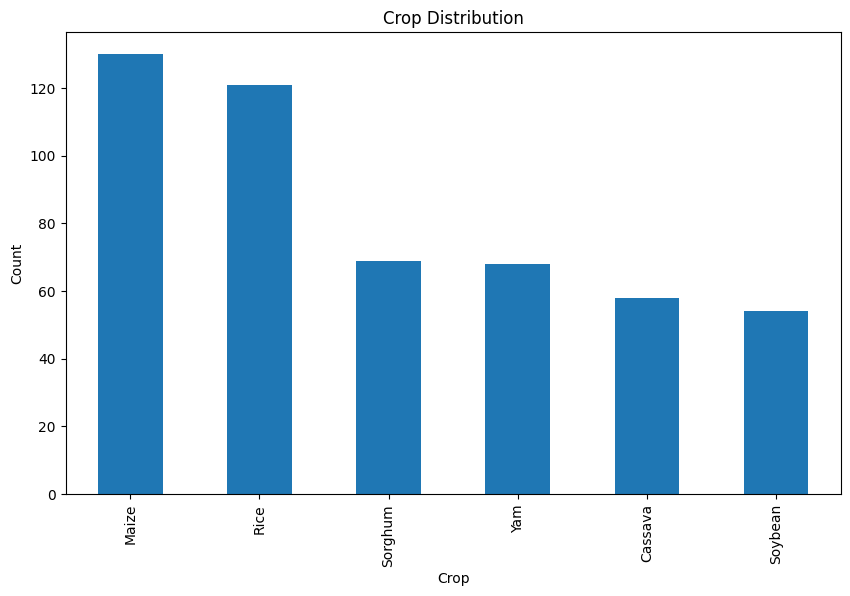

In [28]:
#Crop distribution
plt.figure(figsize=(10, 6))
crop_distribution = df1['Crop'].value_counts()
crop_distribution.plot(kind='bar')
plt.title('Crop Distribution')
plt.xlabel('Crop')
plt.ylabel('Count')